In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from src import *

In [2]:
df = pd.read_csv('Data/raw/cell_diagnosis_dev.csv')
df.columns

Index(['CellSize', 'CellShape', 'NucleusDensity', 'ChromatinTexture',
       'CytoplasmSize', 'CellAdhesion', 'MitosisRate', 'NuclearMembrane',
       'GrowthFactor', 'OxygenSaturation', 'Vascularization',
       'InflammationMarkers', 'Diagnosis', 'CellType', 'GeneticMutation'],
      dtype='object')

In [3]:
df.head()

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
0,63.423148,0.500594,1.473261,23.300222,NaN,0.477657,3.434832,2.492852,-10.000000,78.625935,5.727217,41.158399,0.0,Epthlial,Absnt
1,72.906362,0.474808,1.361360,21.336137,29.856233,0.481035,2.702433,2.281137,63.084699,NaN,5.319552,NaN,1.0,Epthlial,Presnt
2,70.711969,0.481701,NaN,21.521406,30.582427,0.472651,2.786606,2.318029,61.347022,NaN,NaN,NaN,1.0,???,Absnt
3,73.210206,NaN,1.427612,22.437077,29.887970,0.439511,2.998380,2.149232,64.047169,80.693058,NaN,37.843069,1.0,Mesnchymal,Presnt
4,68.348288,NaN,1.454116,21.150723,28.328197,NaN,2.987601,NaN,62.197197,81.737990,4.347438,43.444881,1.0,Epthlial,Presnt


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CellSize             1333 non-null   float64
 1   CellShape            1347 non-null   float64
 2   NucleusDensity       1362 non-null   float64
 3   ChromatinTexture     1366 non-null   float64
 4   CytoplasmSize        1347 non-null   float64
 5   CellAdhesion         1369 non-null   float64
 6   MitosisRate          1343 non-null   float64
 7   NuclearMembrane      1343 non-null   float64
 8   GrowthFactor         1359 non-null   float64
 9   OxygenSaturation     1375 non-null   float64
 10  Vascularization      1347 non-null   float64
 11  InflammationMarkers  1358 non-null   float64
 12  Diagnosis            1663 non-null   float64
 13  CellType             1407 non-null   object 
 14  GeneticMutation      1663 non-null   object 
dtypes: float64(13), object(2)
memory usage

In [5]:
df.describe()

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis
count,1333.000000,1347.000000,1362.000000,1366.000000,1347.000000,1369.000000,1343.000000,1343.000000,1359.000000,1375.000000,1347.000000,1358.000000,1663.000000
mean,83.247087,0.598657,2.097344,26.094973,33.989815,0.548800,5.326484,2.825365,74.126375,93.199374,5.968017,47.725954,0.450391
std,100.316719,0.565438,4.987573,24.842157,32.809627,0.612232,11.572456,2.697956,77.819461,82.574244,5.649530,44.133737,0.497683
min,-100.000000,-1.413038,-3.000000,10.000000,5.000000,-4.461755,-50.000000,-3.438990,-50.000000,-10.000000,-0.997057,0.000000,0.000000
25%,66.572149,0.479758,1.397010,21.279126,26.304514,0.456400,2.776731,2.254502,58.170436,79.130570,4.782475,37.513981,0.000000
50%,69.704323,0.498832,1.445035,22.066810,28.448318,0.474836,3.080247,2.414464,60.993969,79.987328,5.068099,40.859154,0.000000
75%,72.653147,0.523018,1.485651,22.823319,30.506774,0.494613,3.423066,2.534339,63.041642,80.986905,5.346464,43.913527,1.000000
max,1000.000000,5.048566,50.000000,263.793425,299.350559,5.029925,100.000000,24.871762,563.622684,807.181058,54.512433,440.902261,1.000000


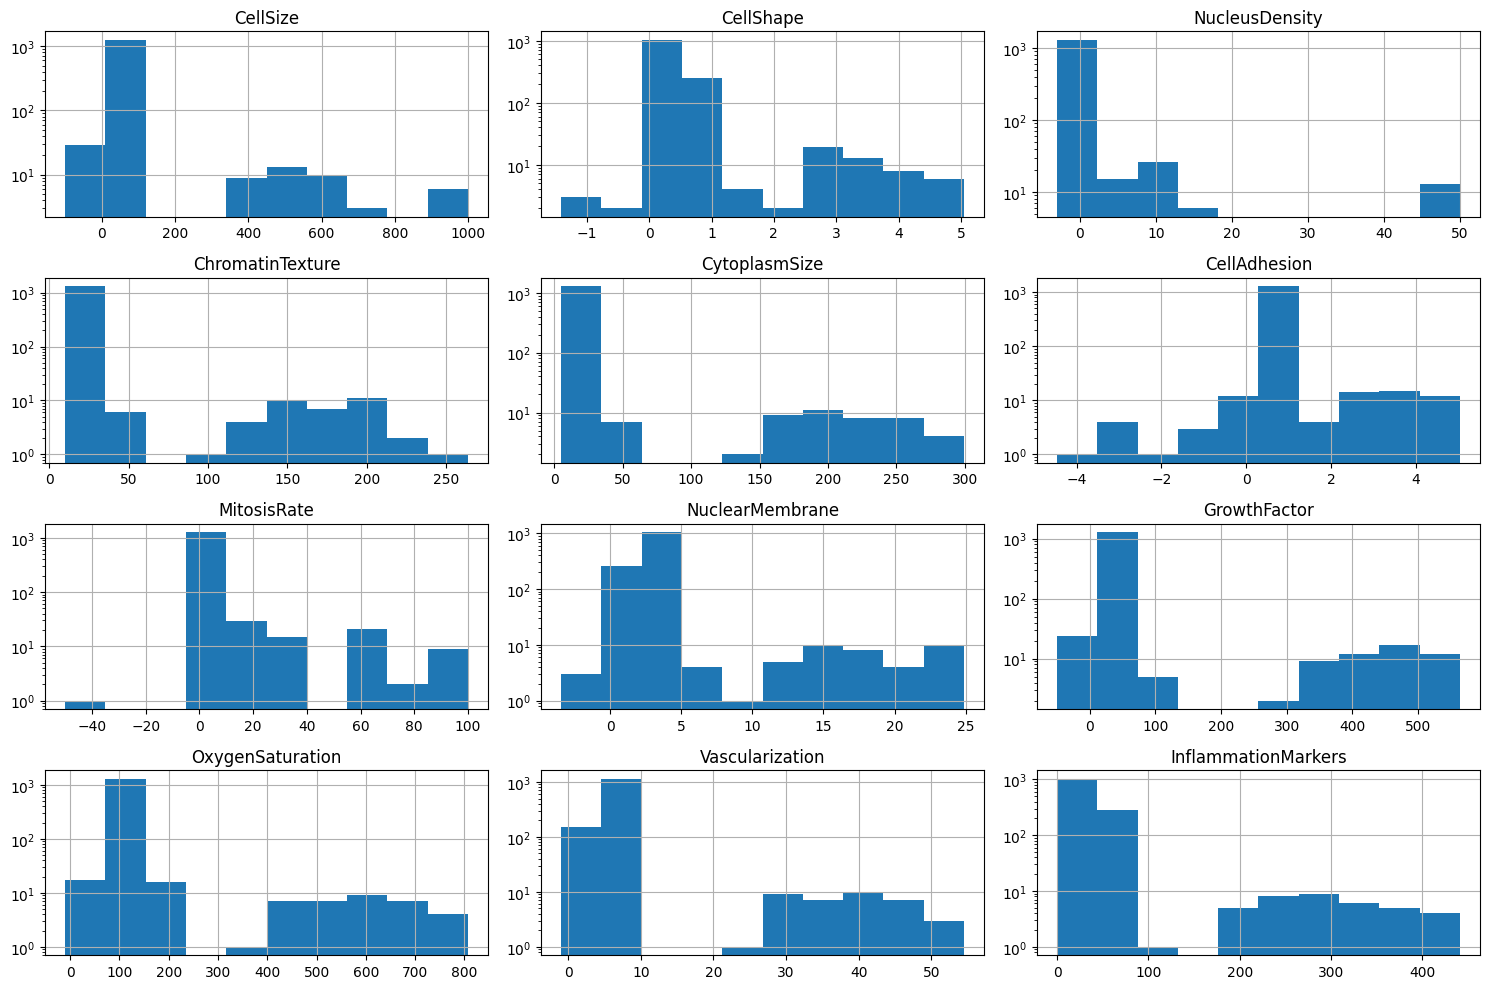

In [7]:
df.drop(columns=["Diagnosis"]).hist(figsize=(15, 10), log=True)
plt.tight_layout()
plt.show()

In [12]:
def clean_data(df):
    # Replace out-of-range or negative values with NaN
    df['CellAdhesion'] = df['CellAdhesion'].apply(lambda x: x if 0 <= x <= 1 else np.nan)
    df['NuclearMembrane'] = df['NuclearMembrane'].apply(lambda x: x if 1 <= x <= 5 else np.nan)
    df['OxygenSaturation'] = df['OxygenSaturation'].apply(lambda x: x if 0 <= x <= 100 else np.nan)
    df['Vascularization'] = df['Vascularization'].apply(lambda x: x if 0 <= x <= 10 else np.nan)
    df['InflammationMarkers'] = df['InflammationMarkers'].apply(lambda x: x if 0 <= x <= 100 else np.nan)
    # Replace '???' in CellType with NaN
    df['CellType'] = df['CellType'].apply(lambda x: x if x != '???' else np.nan)
    # Replace negative values with NaN
    df = df.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
    # Replace outliers with NaN using IQR method
    numeric_columns = [
        "CellSize", "CellShape", "NucleusDensity", "ChromatinTexture",
        "CytoplasmSize", "CellAdhesion", "MitosisRate", "NuclearMembrane",
        "GrowthFactor", "OxygenSaturation", "Vascularization", "InflammationMarkers"
    ]
    Q1 = df[numeric_columns].quantile(0.25)
    Q3 = df[numeric_columns].quantile(0.75)
    IQR = Q3 - Q1
    # Identify outliers and replace them with NaN
    for column in numeric_columns:
        df[column] = df[column].mask(
            (df[column] < (Q1[column] - 1.5 * IQR[column])) | 
            (df[column] > (Q3[column] + 1.5 * IQR[column]))
        )
    # Add a column with NaN counts per row and sort by it
    df['NaN_Count'] = df.isna().sum(axis=1)  # Count NaN values per row
    df = df.sort_values(by='NaN_Count', ascending = False)  # Sort by NaN_Count column
    df = df[df['NaN_Count'] < 7]
    return df.drop(columns=['NaN_Count'])

df_clean = clean_data(df.copy())
df_clean.head()

/tmp/ipykernel_42449/1259724388.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)


,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
1656,NaN,0.468303,1.431114,NaN,29.505344,0.464692,NaN,2.260996,NaN,80.841780,NaN,40.971334,1.0,NaN,Presnt
551,NaN,NaN,1.422623,21.403374,28.020137,0.476367,3.043971,NaN,63.038444,82.018676,NaN,NaN,1.0,NaN,Absnt
557,NaN,0.525569,1.438350,22.739350,29.766801,NaN,NaN,2.225074,62.825573,80.622777,NaN,NaN,0.0,NaN,Absnt
559,63.573134,NaN,NaN,22.655971,23.416163,0.508468,3.354891,NaN,NaN,NaN,4.762448,NaN,0.0,Mesnchymal,Absnt
603,65.469096,NaN,1.494324,NaN,NaN,0.497108,3.390746,NaN,NaN,80.297023,5.055881,44.450380,0.0,NaN,Presnt


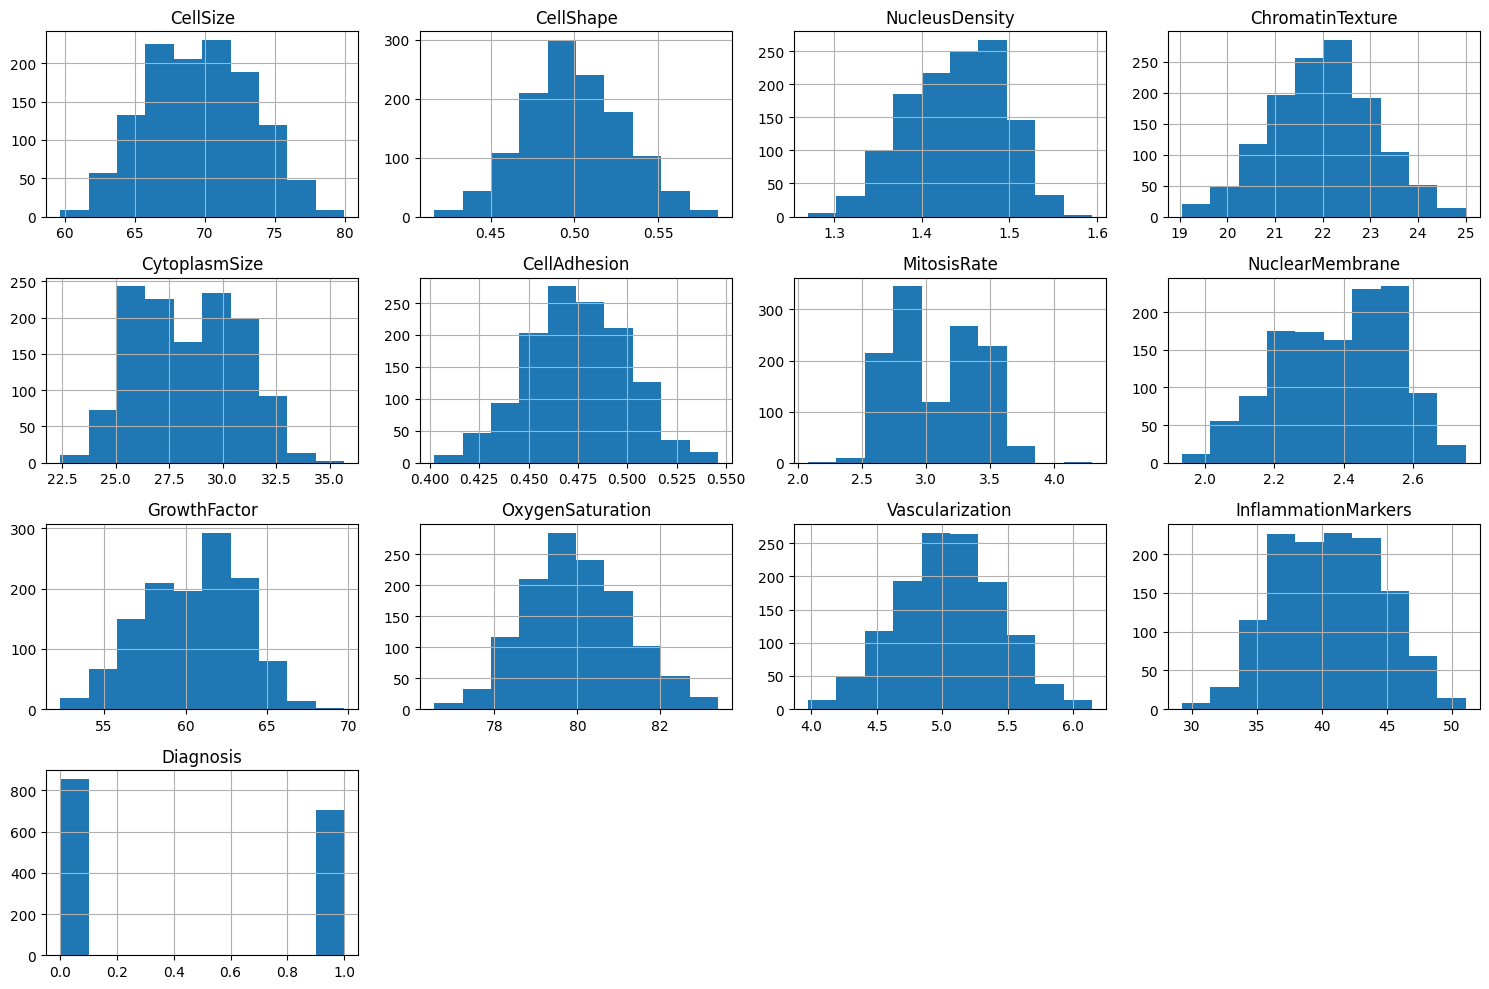

In [13]:
df_clean.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [ ]:
df[df['CellSize'] <= 0].head()

In [ ]:
df['CellSize'] = df['CellSize'].apply(lambda x: np.nan if x < 0 else x)

In [ ]:
df[df['CellShape'] <= 0].head()

In [ ]:
df['Epthlial'] = (df['CellType'] == 'Epthlial').astype(int)
df['Mesnchymal'] = (df['CellType'] == 'Mesnchymal').astype(int)
df['GeneticMutation'] = (df['GeneticMutation'] == 'Presnt').astype(int)

In [ ]:
numerical_columns = [
    "CellSize", "CellShape", "NucleusDensity", "ChromatinTexture",
    "CytoplasmSize", "CellAdhesion", "MitosisRate", "NuclearMembrane",
    "GrowthFactor", "OxygenSaturation", "Vascularization", "InflammationMarkers",
]

# 2. Boxplots de variables numéricas según la variable objetivo "Diagnosis"

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    df.boxplot(column=col, by="Diagnosis", ax=axes[i])
    axes[i].set_title(f"Boxplot de {col} por Diagnosis")
    axes[i].set_xlabel("Diagnosis")
    axes[i].set_ylabel(col)

# Eliminar títulos automáticos generados por Pandas
plt.suptitle("")
plt.tight_layout()
plt.show()

# 3. Matriz de dispersión (scatter matrix) para las variables numéricas

In [ ]:
numerical_columns.extend(['Epthlial', 'Mesnchymal', 'GeneticMutation'])
scatter_matrix(df[numerical_columns], figsize=(15, 15), diagonal='kde')
plt.suptitle("Matriz de dispersión de variables numéricas", y=0.9)
plt.show()

# 4. Gráficos de barras para las variables categóricas

In [ ]:
categorical_columns = ["CellType", "GeneticMutation"]
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_columns), figsize=(12, 6))

for i, col in enumerate(categorical_columns):
    value_counts = df[col].value_counts(dropna=False)
    value_counts.index = value_counts.index.fillna('NaN')  # Reemplazar NaN por texto
    value_counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# 5. Mapa de calor de la correlación entre variables numéricas

In [ ]:
corr = df[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", xticklabels=corr.columns, yticklabels=corr.columns)
plt.title("Mapa de calor de la correlación de variables numéricas")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates


In [ ]:

# 2. Pair plot de Seaborn para las variables numéricas con el hue basado en Diagnosis


In [ ]:
sns.pairplot(df, vars=numerical_columns, hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()


In [ ]:

# 4. Clustermap de la correlación entre variables numéricas


In [ ]:
corr = df[numerical_columns].corr()
sns.clustermap(corr, annot=True, cmap="coolwarm", figsize=(10, 8))
plt.title("Clustermap de correlación de variables numéricas")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset (reemplazar 'dataset.csv' con el nombre real)
df = pd.read_csv('Ostrovsky_Eliana_TP2/Problema 1/Data/raw/cell_diagnosis_dev.csv')

# Mostrar información general del dataset
print(df.info())
print(df.describe())

# --- LIMPIEZA DE DATOS --- #
# Corregir errores ortográficos en variables categóricas
df['CellType'] = df['CellType'].replace({'Epthlial': 'Epithelial', 'Mesnchymal': 'Mesenchymal'})
df['GeneticMutation'] = df['GeneticMutation'].replace({'Presnt': 'Present', 'Absnt': 'Absent'})

# Imputar valores nulos en variables categóricas con 'Desconocido'
df['CellType'] = df['CellType'].fillna('Unknown')

# Imputar valores nulos en variables numéricas con la mediana
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    median_value = np.nanmedian(df[col])
    df[col] = np.where(np.isnan(df[col]), median_value, df[col])

# Eliminar valores atípicos (truncar a percentiles 1% y 99%)
for col in num_cols:
    p1, p99 = np.percentile(df[col], [1, 99])
    df[col] = np.clip(df[col], p1, p99)

# --- ANÁLISIS EXPLORATORIO --- #
# Distribución del diagnóstico
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=df, hue='Diagnosis', palette='coolwarm', dodge=False, legend=False)
plt.title('Distribución de Diagnóstico')
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 6))
corr_matrix = np.corrcoef(df[num_cols].T)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=num_cols, yticklabels=num_cols)
plt.title('Matriz de Correlación')
plt.show()

# Comparación de medias entre células normales y anómalas
df_grouped = df.groupby('Diagnosis')[num_cols].mean()
print(df_grouped)

# --- NORMALIZACIÓN DE VARIABLES NUMÉRICAS --- #
means = {}
stds = {}

def standardize(arr, col_name):
    mean = np.mean(arr)
    std = np.std(arr)
    means[col_name] = mean
    stds[col_name] = std
    return (arr - mean) / std

for col in num_cols:
    df[col] = standardize(df[col].values, col)

# Guardar los parámetros de normalización
norm_params = pd.DataFrame({'Variable': list(means.keys()), 'Mean': list(means.values()), 'Std': list(stds.values())})
norm_params.to_csv('normalization_params.csv', index=False)

# Guardar el dataset limpio
df.to_csv('dataset_limpio.csv', index=False)

print("Análisis completado y dataset limpio guardado. Parámetros de normalización almacenados.")
